**A1**

In [ ]:
import torch

torch.manual_seed(0)

print("=== A1 ===\n")

a = torch.randn(3)
b = torch.randn(3, 4)
c = torch.randn(4, 3)

print("a:", a.shape)
print("b:", b.shape)
print("c:", c.shape)
print()

matmul_result = b @ c
print("b @ c:", matmul_result.shape)

elem_result = b * 2
print("b * 2:", elem_result.shape)

broadcast_result = b + a.view(3, 1)
print("b + a.view(3,1):", broadcast_result.shape)

reshaped = b.view(12)
print("b.view(12):", reshaped.shape)

permuted = b.permute(1, 0)
print("b.permute(1,0):", permuted.shape)

flattened = b.flatten()
print("b.flatten():", flattened.shape)

=== A1 ===

a: torch.Size([3])
b: torch.Size([3, 4])
c: torch.Size([4, 3])

b @ c: torch.Size([3, 3])
b * 2: torch.Size([3, 4])
b + a.view(3,1): torch.Size([3, 4])
b.view(12): torch.Size([12])
b.permute(1,0): torch.Size([4, 3])
b.flatten(): torch.Size([12])


**A2**

In [ ]:
print("\n=== A2 ===\n")

x = torch.tensor(3.0)
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

y = (w * x + b) ** 2
y.backward()

print("Autograd:")
print("dw =", w.grad.item())
print("db =", b.grad.item())

with torch.no_grad():
    manual_dw = 2 * (w * x + b) * x
    manual_db = 2 * (w * x + b)

print("\nManual:")
print("dw =", manual_dw.item())
print("db =", manual_db.item())

print("\nDifference:")
print("dw diff =", abs(w.grad - manual_dw).item())
print("db diff =", abs(b.grad - manual_db).item())


=== A2 ===

Autograd:
dw = 42.0
db = 14.0

Manual:
dw = 42.0
db = 14.0

Difference:
dw diff = 0.0
db diff = 0.0


**B1**

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)

print("=== B1 ===\n")

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))
print()

classes = train_loader.dataset.dataset.classes
print("Classes:", classes)

images, labels = next(iter(train_loader))
print("\nOne batch shape:", images.shape)
print("Labels shape:", labels.shape)

=== B1 ===



100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


Train size: 40000
Validation size: 10000
Test size: 10000

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

One batch shape: torch.Size([128, 3, 32, 32])
Labels shape: torch.Size([128])


**B2**


=== B2 ===

Single image shape: torch.Size([3, 32, 32])
Label: 6 - frog


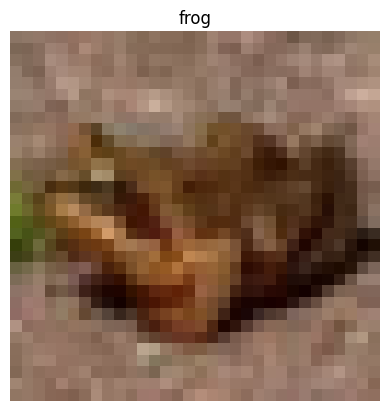

In [ ]:
print("\n=== B2 ===\n")

# Single sample
img, label = train_loader.dataset[0]
print("Single image shape:", img.shape)
print("Label:", label, "-", classes[label])

plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
plt.title(classes[label])
plt.axis("off")
plt.show()

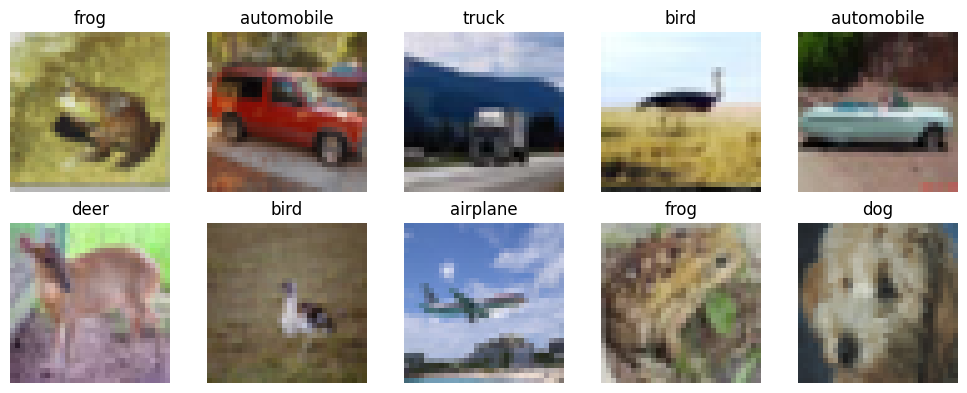

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax in axes.flatten():
    idx = torch.randint(0, len(train_loader.dataset), (1,)).item()
    img, label = train_loader.dataset[idx]
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

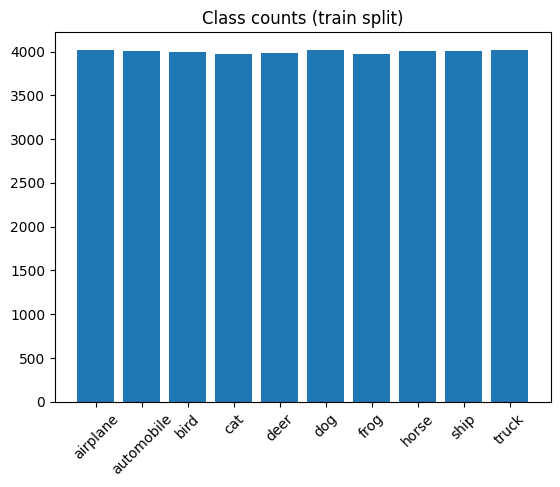

Class counts: [4014 4002 3995 3977 3982 4019 3975 4010 4010 4016]


In [ ]:
targets = [train_loader.dataset.dataset.targets[i]
           for i in train_loader.dataset.indices]

counts = np.bincount(targets)

plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.title("Class counts (train split)")
plt.show()

print("Class counts:", counts)

**B3**

In [ ]:
print("\n=== B3 ===\n")

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

transform_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_dataset_full = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transform_norm
)

train_dataset_norm, val_dataset_norm = random_split(
    train_dataset_full, [train_size, val_size]
)

train_loader = DataLoader(train_dataset_norm, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset_norm, batch_size=128, shuffle=False)

print("Mean used:", mean)
print("Std used:", std)


=== B3 ===

Mean used: (0.4914, 0.4822, 0.4465)
Std used: (0.247, 0.2435, 0.2616)


**C1**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*32*32, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

model = MLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 15

Device: cpu


**C2**

In [ ]:
train_losses = []
train_accuracies = []
val_accuracies = []

best_val_acc = 0
best_epoch = 0

start_time = time.time()

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pt")

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.4f} "
          f"Val Acc: {val_acc:.4f}")

end_time = time.time()
print("Best Val Acc:", best_val_acc, "at epoch", best_epoch)
print("Training time (sec):", round(end_time - start_time, 2))

Epoch [1/15] Loss: 1.6704 Train Acc: 0.4096 Val Acc: 0.4520
Epoch [2/15] Loss: 1.4600 Train Acc: 0.4858 Val Acc: 0.4744
Epoch [3/15] Loss: 1.3481 Train Acc: 0.5251 Val Acc: 0.4958
Epoch [4/15] Loss: 1.2622 Train Acc: 0.5553 Val Acc: 0.5114
Epoch [5/15] Loss: 1.1884 Train Acc: 0.5807 Val Acc: 0.5158
Epoch [6/15] Loss: 1.1188 Train Acc: 0.6043 Val Acc: 0.5177
Epoch [7/15] Loss: 1.0508 Train Acc: 0.6288 Val Acc: 0.5148
Epoch [8/15] Loss: 0.9870 Train Acc: 0.6525 Val Acc: 0.5179
Epoch [9/15] Loss: 0.9265 Train Acc: 0.6735 Val Acc: 0.5222
Epoch [10/15] Loss: 0.8704 Train Acc: 0.6939 Val Acc: 0.5255
Epoch [11/15] Loss: 0.8110 Train Acc: 0.7146 Val Acc: 0.5187
Epoch [12/15] Loss: 0.7669 Train Acc: 0.7297 Val Acc: 0.5194
Epoch [13/15] Loss: 0.7120 Train Acc: 0.7481 Val Acc: 0.5070
Epoch [14/15] Loss: 0.6633 Train Acc: 0.7643 Val Acc: 0.5185
Epoch [15/15] Loss: 0.6109 Train Acc: 0.7849 Val Acc: 0.5164
Best Val Acc: 0.5255 at epoch 10
Training time (sec): 318.09


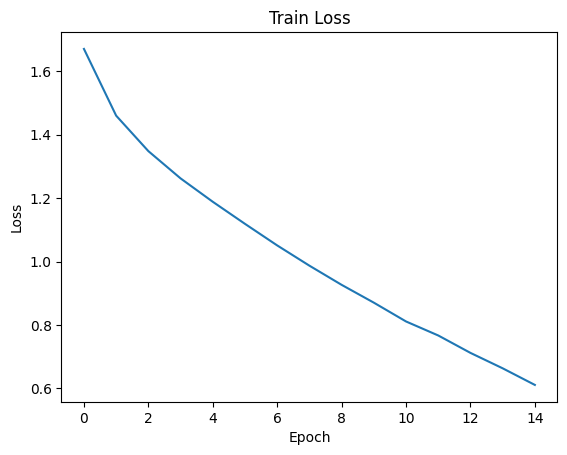

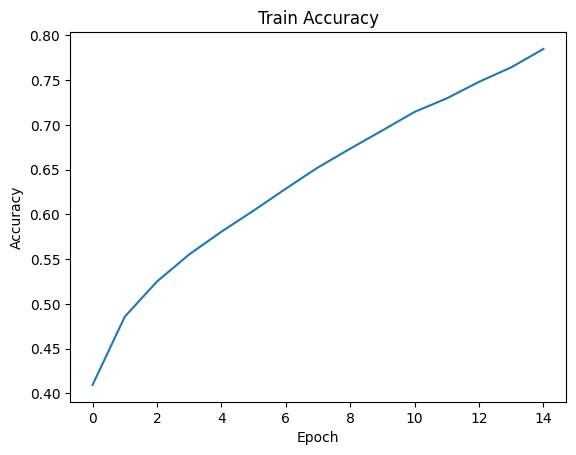

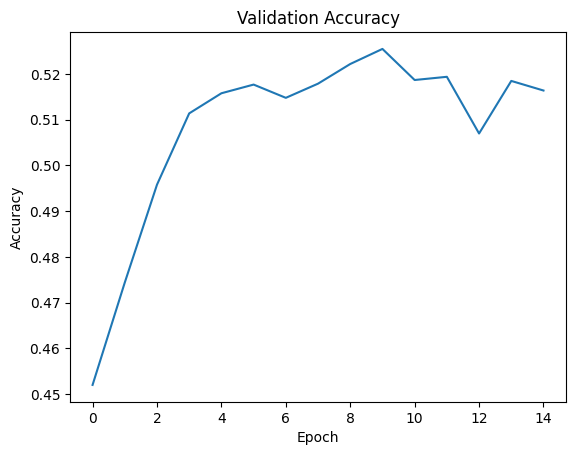

Final Train Accuracy: 0.784875
Final Validation Accuracy: 0.5164


In [ ]:
plt.figure()
plt.plot(train_losses)
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(train_accuracies)
plt.title("Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

print("Final Train Accuracy:", train_accuracies[-1])
print("Final Validation Accuracy:", val_accuracies[-1])

**C3**

In [ ]:
print("Model parameters:\n")

total_params = 0
for name, param in model.named_parameters():
    print(name, param.shape)
    total_params += param.numel()

print("\nTotal parameters:", total_params)

Model parameters:

model.1.weight torch.Size([256, 3072])
model.1.bias torch.Size([256])
model.3.weight torch.Size([128, 256])
model.3.bias torch.Size([128])
model.5.weight torch.Size([10, 128])
model.5.bias torch.Size([10])

Total parameters: 820874


**Part D — Experiments (hyperparameters + model capacity)**

In [ ]:
import copy
import time
import pandas as pd

def train_model(model, train_loader, val_loader,
                optimizer, criterion,
                epochs=15, device="cpu",
                weight_decay=0.0, dropout=0.0):

    model = model.to(device)

    best_val_acc = 0
    best_epoch = 0

    train_losses = []
    val_accuracies = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        total = 0
        correct = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            total += labels.size(0)
            correct += outputs.argmax(1).eq(labels).sum().item()

        train_loss = running_loss / total

        model.eval()
        total = 0
        correct = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                total += labels.size(0)
                correct += outputs.argmax(1).eq(labels).sum().item()

        val_acc = correct / total

        train_losses.append(train_loss)
        val_accuracies.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1

    end_time = time.time()

    return {
        "best_val_acc": best_val_acc,
        "final_val_acc": val_accuracies[-1],
        "best_epoch": best_epoch,
        "training_time": round(end_time - start_time, 2)
    }

In [ ]:
class MLP(nn.Module):
    def __init__(self, hidden1=256, hidden2=128, dropout=0.0):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*32*32, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 10)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
results = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

experiments = [
    {"name": "Baseline", "lr":1e-3, "batch":128, "opt":"Adam", "wd":0.0, "dropout":0.0, "h1":256, "h2":128},
    {"name": "LR_3e-4", "lr":3e-4, "batch":128, "opt":"Adam", "wd":0.0, "dropout":0.0, "h1":256, "h2":128},
    {"name": "LR_3e-3", "lr":3e-3, "batch":128, "opt":"Adam", "wd":0.0, "dropout":0.0, "h1":256, "h2":128},
    {"name": "Batch_256", "lr":1e-3, "batch":256, "opt":"Adam", "wd":0.0, "dropout":0.0, "h1":256, "h2":128},
    {"name": "SGD_momentum", "lr":1e-2, "batch":128, "opt":"SGD", "wd":0.0, "dropout":0.0, "h1":256, "h2":128},
    {"name": "Wider_Model", "lr":1e-3, "batch":128, "opt":"Adam", "wd":0.0, "dropout":0.0, "h1":512, "h2":256},
]

for exp in experiments:
    print("Running:", exp["name"])

    train_loader_exp = DataLoader(train_dataset_norm,
                                  batch_size=exp["batch"],
                                  shuffle=True)
    val_loader_exp = DataLoader(val_dataset_norm,
                                batch_size=exp["batch"],
                                shuffle=False)

    model = MLP(hidden1=exp["h1"],
                hidden2=exp["h2"],
                dropout=exp["dropout"])

    if exp["opt"] == "Adam":
        optimizer = optim.Adam(model.parameters(),
                               lr=exp["lr"],
                               weight_decay=exp["wd"])
    else:
        optimizer = optim.SGD(model.parameters(),
                              lr=exp["lr"],
                              momentum=0.9,
                              weight_decay=exp["wd"])

    result = train_model(model,
                         train_loader_exp,
                         val_loader_exp,
                         optimizer,
                         criterion,
                         epochs=15,
                         device=device)

    results.append({**exp, **result})

Running: Baseline
Running: LR_3e-4
Running: LR_3e-3
Running: Batch_256
Running: SGD_momentum
Running: Wider_Model


In [ ]:
df_results = pd.DataFrame(results)
df_results

,name,lr,batch,opt,wd,dropout,h1,h2,best_val_acc,final_val_acc,best_epoch,training_time
0,Baseline,0.0010,128,Adam,0.0,0.0,256,128,0.5289,0.5170,6,304.90
1,LR_3e-4,0.0003,128,Adam,0.0,0.0,256,128,0.5338,0.5292,10,332.78
2,LR_3e-3,0.0030,128,Adam,0.0,0.0,256,128,0.5048,0.4995,11,343.65
3,Batch_256,0.0010,256,Adam,0.0,0.0,256,128,0.5286,0.5249,11,301.07
4,SGD_momentum,0.0100,128,SGD,0.0,0.0,256,128,0.5320,0.5285,11,291.96
5,Wider_Model,0.0010,128,Adam,0.0,0.0,512,256,0.5303,0.5189,8,380.24
